In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import os

pd.set_option('display.width', 150)
OUT_DIR = 'outputs'; FIG_DIR = 'outputs/figures'; os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng(0)

d = pd.read_parquet(f'{OUT_DIR}/analytic_with_weights.parquet')
T = d['T'].values; w = d['overlap_weight'].values
y = pd.to_numeric(d['oop_total'], errors='coerce').astype(float).values
CONF = ['age','mariee','revenu_ord','instruction_ord','agri_elevage','nb_grossesses',
        'nb_enfants','antecedent_complication','accouchement_dystocique','wealth_index']
print('Chargé :', d.shape)

Chargé : (654, 26)


In [2]:
def wquantile(x, wts, q):
    o = np.argsort(x); x, wts = x[o], wts[o]
    cw = np.cumsum(wts) - 0.5 * wts; cw /= wts.sum()
    return np.interp(q, cw, x)

def qte_vector(yy, Tt, ww, grid):
    return np.array([wquantile(yy[Tt == 1], ww[Tt == 1], q) - wquantile(yy[Tt == 0], ww[Tt == 0], q)
                     for q in grid])

def fit_weights(data):
    X = pd.concat([data[CONF], pd.get_dummies(data['site'], prefix='s', drop_first=True)], axis=1).astype(float)
    Xz = StandardScaler().fit_transform(X)
    e = LogisticRegression(C=1.0, max_iter=3000).fit(Xz, data['T'].values).predict_proba(Xz)[:, 1]
    Tt = data['T'].values
    return np.where(Tt == 1, 1 - e, e)

grid = np.round(np.arange(0.05, 0.96, 0.05), 2)     # 5e au 95e centile
point = qte_vector(y, T, w, grid)

In [3]:
it, ic = np.where(T == 1)[0], np.where(T == 0)[0]; B = 600
boot = np.zeros((B, len(grid))); tail = np.zeros(B)
for b in range(B):
    bi = np.concatenate([rng.choice(it, len(it), True), rng.choice(ic, len(ic), True)])
    db = d.iloc[bi]; wb = fit_weights(db)
    yb = pd.to_numeric(db['oop_total'], errors='coerce').astype(float).values
    v = qte_vector(yb, db['T'].values, wb, grid); boot[b] = v
    tail[b] = v[-2] - v[1]                            # QTE(90e) - QTE(10e)
lo = np.percentile(boot, 2.5, axis=0); hi = np.percentile(boot, 97.5, axis=0)

R = pd.DataFrame({'quantile': (grid * 100).astype(int), 'effet_FCFA': point.round(0),
                  'IC_bas': lo.round(0), 'IC_haut': hi.round(0),
                  'signif': ['✓' if (l < 0) == (h < 0) else '—' for l, h in zip(lo, hi)]})
print(R.to_string(index=False))
tl, th = np.percentile(tail, [2.5, 97.5])
print('\nPente queue-vs-bas  QTE(90e)-QTE(10e) = %.0f FCFA  IC95 [%.0f ; %.0f]  -> %s' %
      (point[-2] - point[1], tl, th,
       'protection CROISSANTE vers la queue (significative)' if th < 0 else 'pente non concluante'))

 quantile  effet_FCFA    IC_bas  IC_haut signif
        5     -7977.0  -15497.0  -3520.0      ✓
       10    -14344.0  -20580.0  -8995.0      ✓
       15    -19000.0  -22548.0 -12026.0      ✓
       20    -19500.0  -23502.0 -14500.0      ✓
       25    -19456.0  -24251.0 -14529.0      ✓
       30    -19227.0  -25002.0 -13977.0      ✓
       35    -19140.0  -24449.0 -13600.0      ✓
       40    -18405.0  -24237.0 -14168.0      ✓
       45    -18575.0  -24777.0 -12839.0      ✓
       50    -19220.0  -26807.0 -13259.0      ✓
       55    -21500.0  -28408.0 -14101.0      ✓
       60    -25232.0  -33379.0 -16434.0      ✓
       65    -26852.0  -35038.0 -18249.0      ✓
       70    -28559.0  -36885.0 -18844.0      ✓
       75    -30000.0  -44759.0 -20849.0      ✓
       80    -39080.0  -46924.0 -21546.0      ✓
       85    -36054.0  -51718.0 -23696.0      ✓
       90    -37253.0  -58396.0 -17709.0      ✓
       95    -40052.0 -116700.0 -13371.0      ✓

Pente queue-vs-bas  QTE(90e)-QTE(10e) =

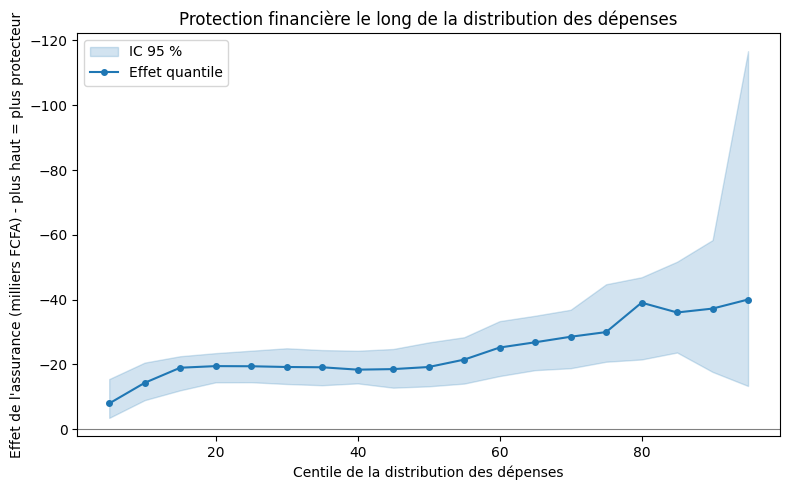

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(grid * 100, lo / 1000, hi / 1000, alpha=0.2, color='#1f77b4', label='IC 95 %')
ax.plot(grid * 100, point / 1000, '-o', color='#1f77b4', ms=4, label='Effet quantile')
ax.axhline(0, color='grey', lw=0.8)
ax.invert_yaxis()
ax.set_xlabel('Centile de la distribution des dépenses')
ax.set_ylabel('Effet de l\'assurance (milliers FCFA) - plus haut = plus protecteur')
ax.set_title('Protection financière le long de la distribution des dépenses')
ax.legend(); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/courbe_quantile.png', dpi=150)
plt.show()

In [5]:
R.to_csv(f'{OUT_DIR}/effets_quantiles.csv', index=False, encoding='utf-8-sig')
print('Sauvegardé : effets_quantiles.csv, figure courbe_quantile.png')

Sauvegardé : effets_quantiles.csv, figure courbe_quantile.png
